# Analiza cyklicznego ściskania — krzywe naprężenie–odkształcenie i pole histerezy

Dane: pliki `820 dz-1.csv`, `820 dz-2.csv`, `820 dz-3.csv` — jeden ciągły pomiar z maszyny wytrzymałościowej (próbkowanie 100 Hz), pocięty przez oprogramowanie na części co 90 000 wierszy.

Kolumny: Czas [s], Siła [N], Przemieszczenie [mm], Naprężenie [N/mm² = MPa], Rozstaw [mm].

Zakres analizy:
1. Wykres σ–ε (stress [MPa] vs strain [%]) dla kolejnych cykli ściskania.
2. Pole histerezy każdego cyklu — z rozdzieleniem na histerezę materiału (σ ≥ 0) i pracę adhezji (klejenie do płyty, σ < 0).
3. Moduły sieczne, zmiękczenie (efekt Mullinsa), odkształcenie trwałe (permanent set), resilience.
4. Stabilizacja histerezy — dopasowanie zaniku wykładniczego i asymptota W∞.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams['figure.dpi'] = 110
OKNO_WYGLADZANIA = 51  # okno średniej ruchomej do modułów/progów (całki na surowych danych)

## 1. Wczytanie danych

Pliki są w kodowaniu Windows-1250, z przecinkiem dziesiętnym; pierwsze 3 wiersze to nagłówki (`aq`, nazwy kolumn, jednostki).

In [2]:
files = ['820 dz-1.csv', '820 dz-2.csv', '820 dz-3.csv']
cols = ['czas_s', 'sila_N', 'przemieszczenie_mm', 'naprezenie_MPa', 'rozstaw_mm']

df = pd.concat(
    [pd.read_csv(f, encoding='cp1250', skiprows=3, names=cols, decimal=',', quotechar='"') for f in files],
    ignore_index=True,
).sort_values('czas_s').reset_index(drop=True)

print(f'Liczba punktów: {len(df)}, czas: {df.czas_s.iloc[0]:.2f}–{df.czas_s.iloc[-1]:.2f} s')
df.head()

Liczba punktów: 199117, czas: 0.00–1991.16 s


,czas_s,sila_N,przemieszczenie_mm,naprezenie_MPa,rozstaw_mm
0,0.00,0.420094,0.0,0.002377,3.313499
1,0.01,0.417630,0.0,0.002363,3.313499
2,0.02,0.415802,0.0,0.002353,3.313499
3,0.03,0.414928,0.0,0.002348,3.313499
4,0.04,0.414610,0.0,0.002346,3.313499


## 2. Odkształcenie

Rozstaw płyt na początku pomiaru (przy przemieszczeniu 0) to wysokość początkowa próbki h₀.
Odkształcenie inżynierskie: ε = przemieszczenie / h₀ (dodatnie = ściskanie). Naprężenie maszyna podaje już w N/mm² (= MPa).

In [3]:
h0 = df['rozstaw_mm'].iloc[0]
df['strain'] = df['przemieszczenie_mm'] / h0          # odkształcenie [-]
df['strain_pct'] = df['strain'] * 100                  # [%]

print(f'h0 = {h0:.4f} mm')
print(f'maks. odkształcenie = {df.strain_pct.max():.1f} %')
print(f'maks. naprężenie    = {df.naprezenie_MPa.max():.4f} MPa')

h0 = 3.3135 mm
maks. odkształcenie = 90.1 %
maks. naprężenie    = 0.6867 MPa


## 3. Podział na cykle

Między cyklami trawersa odjeżdża od próbki (przemieszczenie ujemne, siła ≈ 0). Cykl = spójny odcinek, w którym przemieszczenie > 0 (kontakt z próbką).

Pierwsze ściśnięcie jest wyraźnie sztywniejsze od pozostałych (materiał „dziewiczy") — traktujemy je jako **preload (kondycjonowanie)**, a właściwe cykle numerujemy 1–5.

In [4]:
PROG_MM = 0.02      # margines na szum wokół zera
MIN_PUNKTOW = 200   # odrzuć krótkie przypadkowe przejścia przez zero

w_kontakcie = (df['przemieszczenie_mm'] > PROG_MM).to_numpy()
zmiany = np.flatnonzero(np.diff(w_kontakcie.astype(int)))
granice = np.concatenate([[0], zmiany + 1, [len(df)]])

cykle = []
for a, b in zip(granice[:-1], granice[1:]):
    if w_kontakcie[a] and b - a >= MIN_PUNKTOW:
        cykle.append(df.iloc[a:b])

nazwy = ['preload'] + [f'cykl {i}' for i in range(1, len(cykle))] if len(cykle) >= 2 \
    else [f'cykl {i+1}' for i in range(len(cykle))]

print(f'Wykryto ściśnięć: {len(cykle)}')
for nazwa, c in zip(nazwy, cykle):
    print(f'  {nazwa:8s}: t = {c.czas_s.iloc[0]:7.1f}–{c.czas_s.iloc[-1]:7.1f} s, '
          f'F_max = {c.sila_N.max():7.2f} N, σ_max = {c.naprezenie_MPa.max():.4f} MPa')

Wykryto ściśnięć: 6
  preload : t =     0.7–   71.9 s, F_max =  106.86 N, σ_max = 0.6047 MPa
  cykl 1  : t =   372.6–  443.7 s, F_max =  121.35 N, σ_max = 0.6867 MPa
  cykl 2  : t =   744.4–  815.5 s, F_max =  117.16 N, σ_max = 0.6630 MPa
  cykl 3  : t =  1116.2– 1187.3 s, F_max =  110.45 N, σ_max = 0.6250 MPa
  cykl 4  : t =  1487.9– 1559.1 s, F_max =  109.45 N, σ_max = 0.6194 MPa
  cykl 5  : t =  1859.7– 1930.9 s, F_max =  109.09 N, σ_max = 0.6173 MPa


## 4. Wykres naprężenie–odkształcenie dla wszystkich cykli

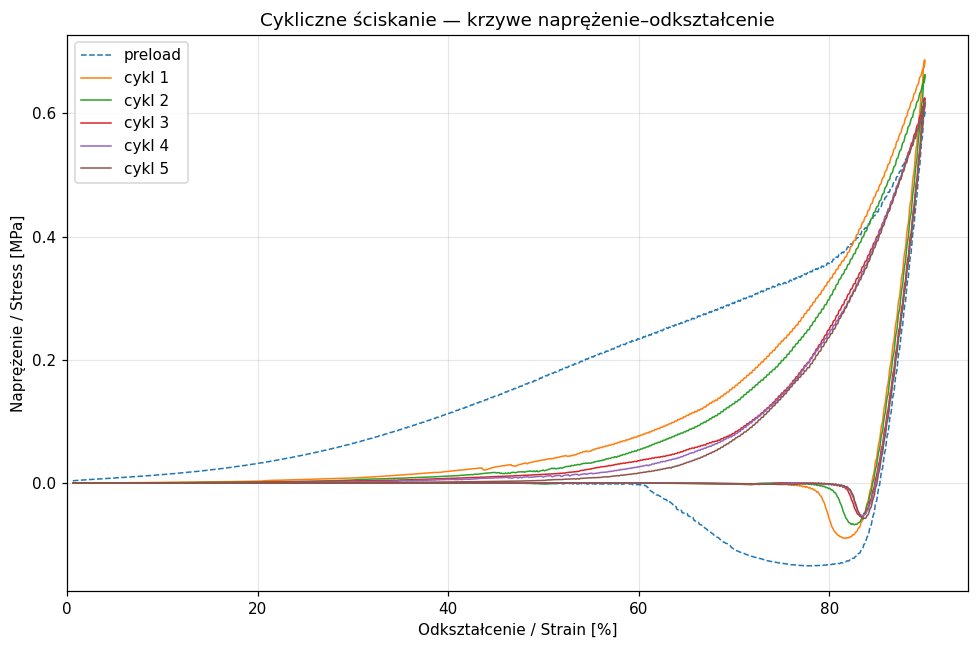

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
kolory = plt.cm.tab10(np.linspace(0, 1, 10))

for i, (nazwa, c) in enumerate(zip(nazwy, cykle)):
    styl = '--' if nazwa == 'preload' else '-'
    ax.plot(c['strain_pct'], c['naprezenie_MPa'], styl, lw=1.0, color=kolory[i], label=nazwa)

ax.set_xlabel('Odkształcenie / Strain [%]')
ax.set_ylabel('Naprężenie / Stress [MPa]')
ax.set_title('Cykliczne ściskanie — krzywe naprężenie–odkształcenie')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
fig.tight_layout()
fig.savefig('wykres_sigma_eps_cykle.png', dpi=200)
plt.show()

## 5. Pole histerezy z rozdzieleniem adhezji

Pole pętli histerezy to całka po zamkniętej pętli W = ∮ σ dε — energia rozproszona w cyklu na jednostkę objętości (jednostka: σ [N/mm²] × ε [–] → **mJ/mm³ = MJ/m³**).

Przy odciążaniu naprężenie schodzi **poniżej zera** (próbka klei się do płyty i ciągnie ją w dół). Ta część pętli to nie histereza materiału, tylko praca odrywania od płyty, dlatego liczymy osobno:
- **histereza σ⁺** = ∮ max(σ,0) dε — właściwa dyssypacja materiału,
- **praca adhezji** = ∮ min(σ,0) dε ≥ 0 — energia odrywania (σ<0 przy dε<0),
- suma obu = pole surowej pętli.

Dyssypacja i resilience liczone z wartości obciętych: dyssypacja = histereza σ⁺ / W_obciążania, resilience = W_odciążania / W_obciążania.

In [6]:
POZIOMY = [0.30, 0.60, 0.85]  # poziomy ε do śledzenia zmiękczenia

def policz_cykl(c):
    eps = c['strain'].to_numpy()
    sig = c['naprezenie_MPa'].to_numpy()
    d = c['przemieszczenie_mm'].to_numpy()
    F = c['sila_N'].to_numpy()
    sig_plus = np.clip(sig, 0, None)
    sig_minus = np.clip(sig, None, 0)
    i_max = int(np.argmax(eps))

    w_obc = np.trapezoid(sig_plus[:i_max + 1], eps[:i_max + 1])
    w_odc = -np.trapezoid(sig_plus[i_max:], eps[i_max:])
    histereza = np.trapezoid(sig_plus, eps)        # histereza materiału (σ⁺)
    adhezja = np.trapezoid(sig_minus, eps)         # praca odrywania od płyty (≥ 0)
    surowa = np.trapezoid(sig, eps)                # = histereza + adhezja
    praca_mJ = np.trapezoid(F, d)

    # gałąź obciążania, wygładzona — moduły, zmiękczenie, próg kontaktu
    sig_w = pd.Series(sig[:i_max + 1]).rolling(OKNO_WYGLADZANIA, center=True, min_periods=1).mean().to_numpy()
    eps_o = eps[:i_max + 1]
    rosnace = np.concatenate([[True], np.diff(np.maximum.accumulate(eps_o)) > 0])
    sig_przy = lambda e: float(np.interp(e, eps_o[rosnace], sig_w[rosnace])) \
        if eps_o[rosnace][0] <= e <= eps_o[rosnace][-1] else np.nan
    modul = lambda e1, e2: (sig_przy(e2) - sig_przy(e1)) / (e2 - e1)

    prog = max(0.005 * sig.max(), 0.001)
    powyzej = np.flatnonzero(sig_w > prog)
    eps_kontaktu = eps_o[powyzej[0]] if len(powyzej) else np.nan

    return {
        'σ_max [MPa]': sig.max(),
        'ε_max [%]': eps.max() * 100,
        'histereza σ⁺ [kJ/m³]': histereza * 1000,
        'praca adhezji [kJ/m³]': adhezja * 1000,
        'histereza surowa [kJ/m³]': surowa * 1000,
        'W obciążania [mJ/mm³]': w_obc,
        'W odciążania [mJ/mm³]': w_odc,
        'dyssypacja [%]': 100 * histereza / w_obc,
        'resilience [%]': 100 * w_odc / w_obc,
        'praca pętli [N·mm]': praca_mJ,
        'E₁₀₋₃₀ [MPa]': modul(0.10, 0.30),
        'E₆₀₋₈₅ [MPa]': modul(0.60, 0.85),
        **{f'σ({int(p*100)}%) [MPa]': sig_przy(p) for p in POZIOMY},
        'ε kontaktu [%]': eps_kontaktu * 100,
    }

tabela = pd.DataFrame([policz_cykl(c) for c in cykle], index=nazwy)
tabela['permanent set [p.p.]'] = tabela['ε kontaktu [%]'] - tabela['ε kontaktu [%]'].iloc[0]
tabela['σ(60%) vs preload [%]'] = 100 * tabela['σ(60%) [MPa]'] / tabela['σ(60%) [MPa]'].iloc[0]

tabela_energia = tabela[['σ_max [MPa]', 'ε_max [%]', 'histereza σ⁺ [kJ/m³]', 'praca adhezji [kJ/m³]',
                         'histereza surowa [kJ/m³]', 'dyssypacja [%]', 'resilience [%]', 'praca pętli [N·mm]']]
tabela_energia.round(3)

,σ_max [MPa],ε_max [%],histereza σ⁺ [kJ/m³],praca adhezji [kJ/m³],histereza surowa [kJ/m³],dyssypacja [%],resilience [%],praca pętli [N·mm]
preload,0.605,90.078,142.059,23.635,165.694,91.575,8.425,97.021
cykl 1,0.687,90.067,75.874,4.023,79.896,81.439,18.561,46.783
cykl 2,0.663,90.082,65.100,2.387,67.487,79.967,20.033,39.516
cykl 3,0.625,90.075,51.481,1.400,52.882,77.742,22.258,30.964
cykl 4,0.619,90.090,49.177,1.341,50.518,77.321,22.679,29.581
cykl 5,0.617,90.078,45.667,1.505,47.172,76.302,23.698,27.621


## 6. Sztywność, zmiękczenie i odkształcenie trwałe

- **Moduły sieczne** E₁₀₋₃₀ i E₆₀₋₈₅ — nachylenie wygładzonej gałęzi obciążania między zadanymi poziomami ε.
- **Zmiękczenie (efekt Mullinsa)** — σ przy ε = 30/60/85% i jego stosunek do pierwszego ściśnięcia.
- **Permanent set** — przyrost ε, przy którym naprężenie zaczyna realnie rosnąć (próg 0,5% σ_max), względem preloadu; miara trwałej deformacji próbki.

In [7]:
tabela_mech = tabela[['E₁₀₋₃₀ [MPa]', 'E₆₀₋₈₅ [MPa]', 'σ(30%) [MPa]', 'σ(60%) [MPa]', 'σ(85%) [MPa]',
                      'σ(60%) vs preload [%]', 'ε kontaktu [%]', 'permanent set [p.p.]']]
tabela_mech.round(4)

,E₁₀₋₃₀ [MPa],E₆₀₋₈₅ [MPa],σ(30%) [MPa],σ(60%) [MPa],σ(85%) [MPa],σ(60%) vs preload [%],ε kontaktu [%],permanent set [p.p.]
preload,0.2534,0.8267,0.0641,0.2339,0.4406,100.0000,0.6036,0.0000
cykl 1,0.0364,1.5895,0.0080,0.0762,0.4736,32.5842,20.7372,20.1336
cykl 2,0.0232,1.5787,0.0048,0.0537,0.4484,22.9579,27.1691,26.5655
cykl 3,0.0153,1.4574,0.0031,0.0360,0.4004,15.3952,30.0853,29.4817
cykl 4,0.0083,1.4841,0.0016,0.0262,0.3972,11.1951,34.8913,34.2877
cykl 5,0.0029,1.5057,0.0005,0.0160,0.3924,6.8376,47.8119,47.2083


## 7. Stabilizacja histerezy

Pole histerezy maleje z numerem cyklu. Dopasowujemy zanik wykładniczy do cykli właściwych (bez preloadu):

W(n) = W∞ + (W₁ − W∞)·e^(−(n−1)/τ)

W∞ to przewidywana energia rozpraszana na cykl po pełnym ustabilizowaniu materiału, τ — liczba cykli charakterystyczna dla zaniku.

In [8]:
wlasciwe = tabela.iloc[1:] if nazwy[0] == 'preload' else tabela
W = wlasciwe['histereza σ⁺ [kJ/m³]'].to_numpy()
n = np.arange(1, len(W) + 1)

model = lambda n, winf, a, tau: winf + a * np.exp(-(n - 1) / tau)
(winf, a, tau), _ = curve_fit(model, n, W, p0=[W[-1], W[0] - W[-1], 2], maxfev=10000)
r2 = 1 - np.sum((W - model(n, winf, a, tau))**2) / np.sum((W - W.mean())**2)
print(f'W∞ = {winf:.1f} kJ/m³,  τ = {tau:.2f} cykli,  R² = {r2:.3f}')

W∞ = 39.3 kJ/m³,  τ = 2.18 cykli,  R² = 0.979


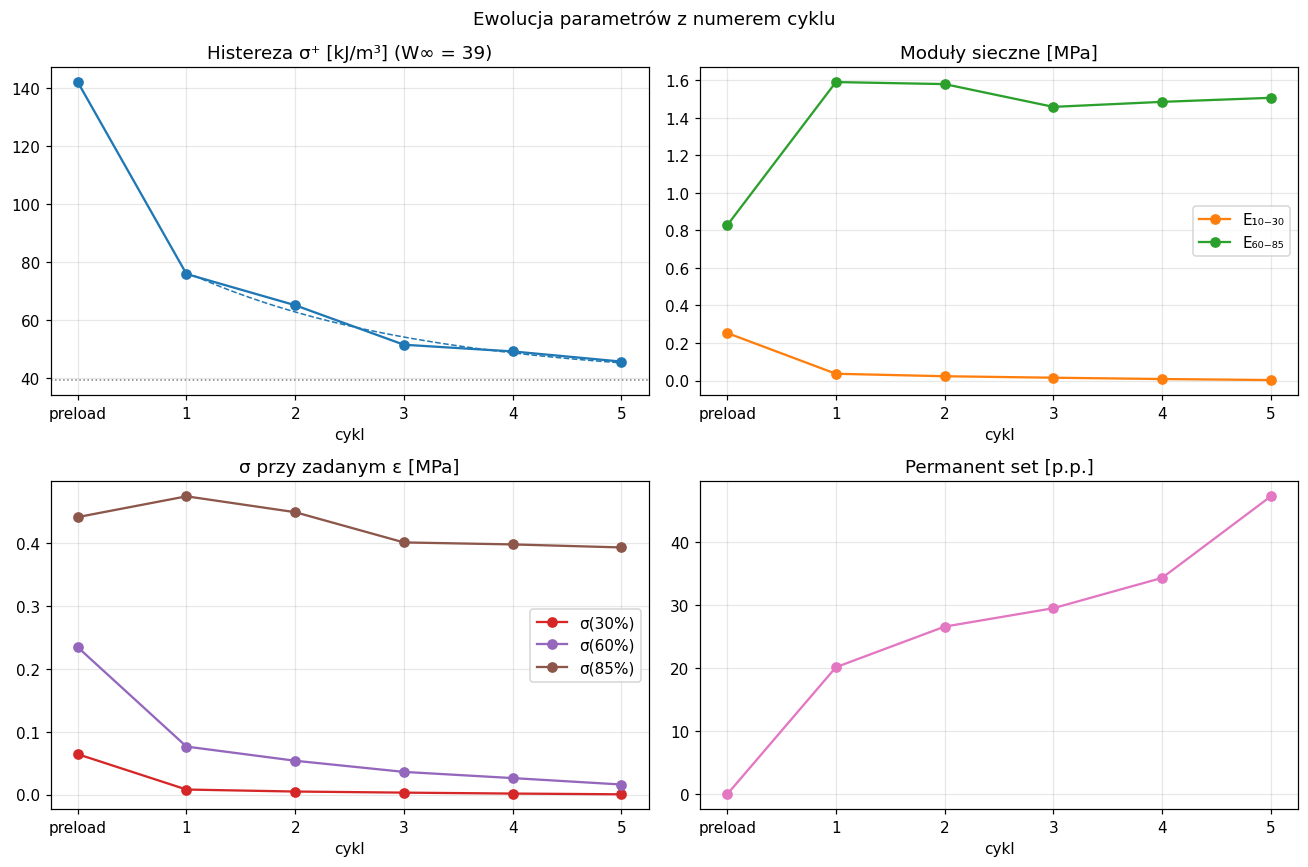

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
x = np.arange(len(tabela))
tick = list(range(len(tabela)))
etyk = [n.replace('cykl ', '') for n in nazwy]

ax = axes[0, 0]
ax.plot(x, tabela['histereza σ⁺ [kJ/m³]'], 'o-', color=kolory[0])
nf = np.linspace(1, len(W), 50)
ax.plot(nf + (0 if nazwy[0] != 'preload' else 0), model(nf, winf, a, tau), '--', color=kolory[0], lw=1)
ax.axhline(winf, color='gray', ls=':', lw=1)
ax.set_title(f'Histereza σ⁺ [kJ/m³] (W∞ = {winf:.0f})')

ax = axes[0, 1]
ax.plot(x, tabela['E₁₀₋₃₀ [MPa]'], 'o-', label='E₁₀₋₃₀', color=kolory[1])
ax.plot(x, tabela['E₆₀₋₈₅ [MPa]'], 'o-', label='E₆₀₋₈₅', color=kolory[2])
ax.set_title('Moduły sieczne [MPa]'); ax.legend()

ax = axes[1, 0]
for k, p in enumerate([30, 60, 85]):
    ax.plot(x, tabela[f'σ({p}%) [MPa]'], 'o-', label=f'σ({p}%)', color=kolory[3 + k])
ax.set_title('σ przy zadanym ε [MPa]'); ax.legend()

ax = axes[1, 1]
ax.plot(x, tabela['permanent set [p.p.]'], 'o-', color=kolory[6])
ax.set_title('Permanent set [p.p.]')

for ax in axes.flat:
    ax.set_xticks(tick, etyk); ax.grid(alpha=0.3); ax.set_xlabel('cykl')
fig.suptitle('Ewolucja parametrów z numerem cyklu')
fig.tight_layout()
fig.savefig('trendy_parametrow.png', dpi=200)
plt.show()

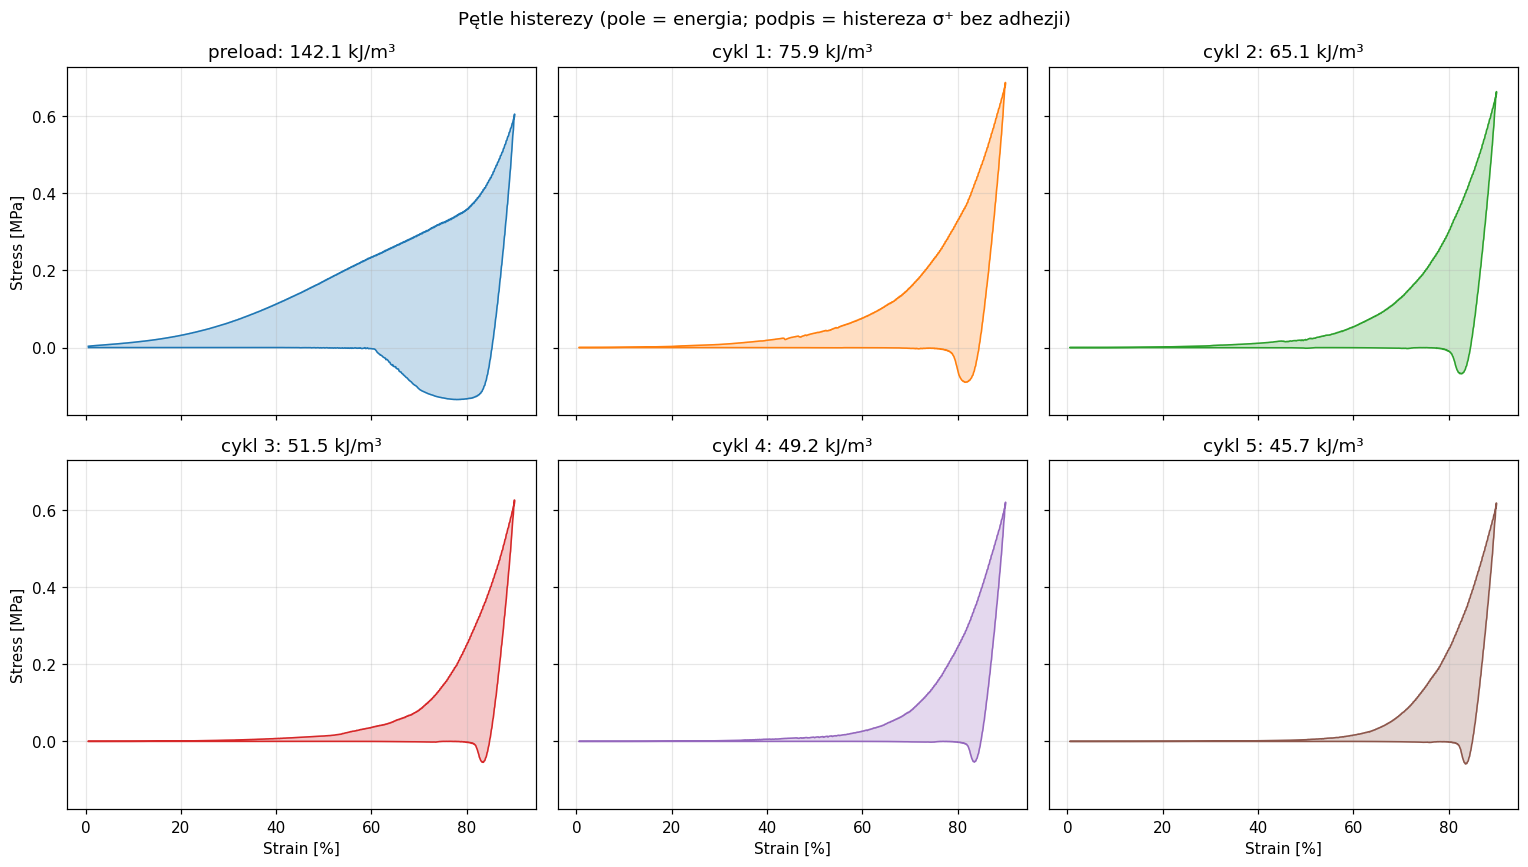

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for ax, nazwa, c, (_, w) in zip(axes.flat, nazwy, cykle, tabela.iterrows()):
    eps = c['strain_pct'].to_numpy()
    sig = c['naprezenie_MPa'].to_numpy()
    i = nazwy.index(nazwa)
    ax.fill(eps, sig, color=kolory[i], alpha=0.25)
    ax.plot(eps, sig, color=kolory[i], lw=1.0)
    ax.set_title(f"{nazwa}: {w['histereza σ⁺ [kJ/m³]']:.1f} kJ/m³")
    ax.grid(alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel('Strain [%]')
for ax in axes[:, 0]:
    ax.set_ylabel('Stress [MPa]')
fig.suptitle('Pętle histerezy (pole = energia; podpis = histereza σ⁺ bez adhezji)')
fig.tight_layout()
fig.savefig('petle_histerezy.png', dpi=200)
plt.show()

In [11]:
tabela.round(5).to_csv('wyniki_histereza.csv', encoding='utf-8-sig')
print('Zapisano: wyniki_histereza.csv, wykres_sigma_eps_cykle.png, petle_histerezy.png, trendy_parametrow.png')

Zapisano: wyniki_histereza.csv, wykres_sigma_eps_cykle.png, petle_histerezy.png, trendy_parametrow.png


## Uwagi metodyczne

- h₀ przyjęto jako rozstaw płyt na początku pomiaru (przemieszczenie = 0). Jeśli rzeczywista wysokość próbki była inna, wystarczy podmienić `h0` w sekcji 2 — naprężenia się nie zmienią, przeskaluje się oś odkształcenia i wartości energii (liniowo).
- Histereza σ⁺ pomija ujemne naprężenia przy odciążaniu (klejenie próbki do płyty) — to one powodowały dyssypację > 100% w preloadzie przy liczeniu na surowej pętli. Praca adhezji raportowana osobno.
- Moduły i progi liczone na gałęzi obciążania wygładzonej średnią ruchomą (okno 51 punktów ≈ 0,5 s); całki energii zawsze na danych surowych.
- Pierwsze ściśnięcie traktowane jako preload (kondycjonowanie, efekt Mullinsa) — jest kilkukrotnie sztywniejsze od kolejnych i wyłączone z dopasowania stabilizacji.
- Te same obliczenia wykonuje portal webowy (`portal/`) — logika JS testowana regresyjnie względem tego notebooka (`testy/portal.test.js`).